# COMPAS EDA: where is the unfairness actually coming from?

If a model is unfair on COMPAS, which of these is the reason?

1. The groups have different base rates (different fraction of people who reoffend)
2. The groups have different feature distributions (e.g. one group has more priors on average)
3. The features mean different things in different groups (the relationship between X and y is
   actually different, so one model cannot describe everyone)

These are three very different problems. Only (3) is a real argument for fitting separate models
per subpopulation

## Part 0: setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score,
                             log_loss, brier_score_loss)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_csv("clean-compas-scores-two-year.csv")

print("rows, cols:", df.shape)
print("overall recidivism rate:", round(df["two_year_recid"].mean(), 4))
df.head()

rows, cols: (6172, 13)
overall recidivism rate: 0.4551


,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,len_of_stay,c_charge_degree,two_year_recid,race_for_model
0,Male,69,Greater than 45,Other,0,0,0,0,-1.0,0,F,0,Other
1,Male,34,25 - 45,African-American,0,0,0,0,-1.0,10,F,1,African-American
2,Male,24,Less than 25,African-American,0,0,1,4,-1.0,1,F,1,African-American
3,Male,44,25 - 45,Other,0,0,0,0,0.0,1,M,0,Other
4,Male,41,25 - 45,Caucasian,0,0,0,14,-1.0,6,F,1,Caucasian


## Part 1: What is in the data

- `two_year_recid` is the label. 1 if rearrested within two years.
- `priors_count`, `juv_fel_count`, `juv_misd_count`, `juv_other_count` are criminal history.
- `age`, `sex`, `race` are the demographics.
- `c_charge_degree` is F (felony) or M (misdemeanor) for the current charge.
- `len_of_stay` is days in jail for the current charge.
- `days_b_screening_arrest` is the gap between arrest and COMPAS screening. ProPublica already
  filtered this to +/- 30 days, so it should not have crazy values.
- `race_for_model` is race collapsed to African-American / Caucasian / Other, because the other
  race categories are too small to fit anything on.

In [3]:
# dtypes and missingness
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "n_unique": df.nunique(),
})
print(info.to_string())
print()
print("duplicate rows:", df.duplicated().sum())

                           dtype  n_missing  n_unique
sex                       object          0         2
age                        int64          0        65
age_cat                   object          0         3
race                      object          0         6
juv_fel_count              int64          0        10
juv_misd_count             int64          0        10
juv_other_count            int64          0         9
priors_count               int64          0        36
days_b_screening_arrest  float64          0        56
len_of_stay                int64          0       241
c_charge_degree           object          0         2
two_year_recid             int64          0         2
race_for_model            object          0         3

duplicate rows: 568


Two things to flag:

- There are 568 duplicate rows. The csv has no id column, so these are rows with identical
  features and label -- likely distinct defendants with the same profile, not data
  errors
- `len_of_stay` has a minimum of -1, which is not physically possible. It is one day of rounding in
  the jail in/out timestamps. Too small to matter, leaving it alone.

In [4]:
# numeric summary. mostly looking for weird values (negatives, huge outliers)
num_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
            "len_of_stay", "days_b_screening_arrest"]
print(df[num_cols].describe().round(2).to_string())

           age  priors_count  juv_fel_count  juv_misd_count  juv_other_count  len_of_stay  days_b_screening_arrest
count  6172.00       6172.00        6172.00         6172.00          6172.00      6172.00                  6172.00
mean     34.53          3.25           0.06            0.09             0.11        14.62                    -1.74
std      11.73          4.74           0.46            0.50             0.47        46.69                     5.08
min      18.00          0.00           0.00            0.00             0.00        -1.00                   -30.00
25%      25.00          0.00           0.00            0.00             0.00         0.00                    -1.00
50%      31.00          1.00           0.00            0.00             0.00         1.00                    -1.00
75%      42.00          4.00           0.00            0.00             0.00         5.00                    -1.00
max      96.00         38.00          20.00           13.00             9.00    

In [5]:
# the juvenile counts are almost all zero, so they are basically sparse flags rather than counts
# worth knowing because a per-group model fit on a small group might see zero variance in these
for c in ["juv_fel_count", "juv_misd_count", "juv_other_count"]:
    print(f"{c:18s} fraction exactly 0: {(df[c] == 0).mean():.3f}   max: {df[c].max()}")

juv_fel_count      fraction exactly 0: 0.966   max: 20
juv_misd_count     fraction exactly 0: 0.943   max: 13
juv_other_count    fraction exactly 0: 0.925   max: 9


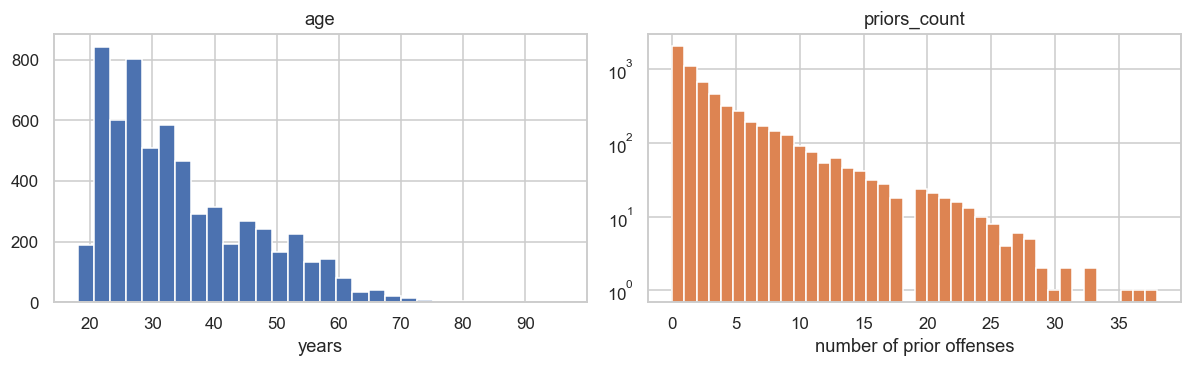

priors_count is very skewed. median: 1.0   mean: 3.25   max: 38


In [6]:
# distributions of the two features that actually carry most of the signal
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(df["age"], bins=30, color="#4C72B0")
axes[0].set_title("age")
axes[0].set_xlabel("years")

axes[1].hist(df["priors_count"], bins=40, color="#DD8452")
axes[1].set_title("priors_count")
axes[1].set_xlabel("number of prior offenses")
axes[1].set_yscale("log")  # long right tail, log scale so the tail is visible

plt.tight_layout()
plt.show()

print("priors_count is very skewed. median:", df["priors_count"].median(),
      "  mean:", round(df["priors_count"].mean(), 2),
      "  max:", df["priors_count"].max())

## Part 2: Group sizes and base rates

First thing to check for any fairness question. If two groups have very different base rates,
then a single model with a single threshold will automatically produce different error rates for
them, even if the model is perfectly calibrated and even if it never sees race.

In [7]:
def group_summary(df, col):
    "n, share of the data, and base rate for each level of a column"
    out = df.groupby(col)["two_year_recid"].agg(n="size", base_rate="mean")
    out["share_of_data"] = out["n"] / len(df)
    return out[["n", "share_of_data", "base_rate"]].round(3)

for col in ["race_for_model", "sex", "age_cat", "c_charge_degree"]:
    print(f"--- {col} ---")
    print(group_summary(df, col).to_string())
    print()

--- race_for_model ---
                     n  share_of_data  base_rate
race_for_model                                  
African-American  3175          0.514      0.523
Caucasian         2103          0.341      0.391
Other              894          0.145      0.365

--- sex ---
           n  share_of_data  base_rate
sex                                   
Female  1175           0.19      0.351
Male    4997           0.81      0.479

--- age_cat ---
                    n  share_of_data  base_rate
age_cat                                        
25 - 45          3532          0.572      0.465
Greater than 45  1293          0.209      0.320
Less than 25     1347          0.218      0.560

--- c_charge_degree ---
                    n  share_of_data  base_rate
c_charge_degree                                
F                3970          0.643      0.500
M                2202          0.357      0.375



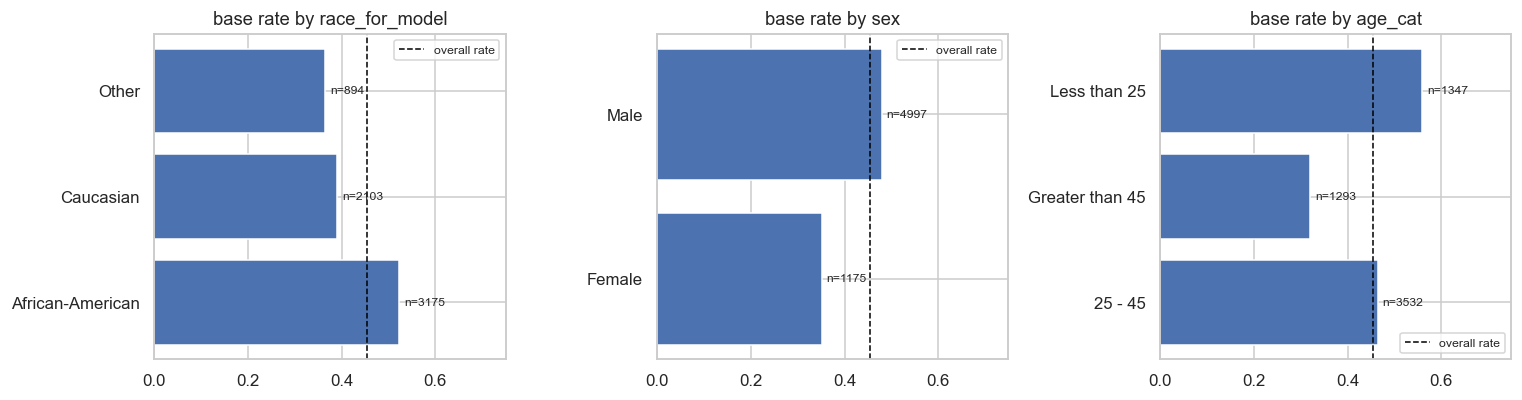

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for ax, col in zip(axes, ["race_for_model", "sex", "age_cat"]):
    s = group_summary(df, col)
    ax.barh(s.index.astype(str), s["base_rate"], color="#4C72B0")
    ax.axvline(df["two_year_recid"].mean(), color="black", ls="--", lw=1,
               label="overall rate")
    ax.set_xlim(0, 0.75)
    ax.set_title(f"base rate by {col}")
    ax.legend(fontsize=8)
    for i, (idx, row) in enumerate(s.iterrows()):
        ax.text(row["base_rate"] + 0.01, i, f"n={int(row['n'])}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Under 25 reoffends at roughly twice the rate of over 45. Race is a smaller gap than age. 
Any model that uses age heavily will produce different error rates by race just because the racial groups have different age distributions.

In [9]:
# intersections
cross = (df.groupby(["race_for_model", "sex", "age_cat"])["two_year_recid"]
           .agg(n="size", base_rate="mean")
           .round(3)
           .reset_index()
           .sort_values("n", ascending=False))
print(cross.to_string(index=False))

  race_for_model    sex         age_cat    n  base_rate
African-American   Male         25 - 45 1563      0.547
       Caucasian   Male         25 - 45  861      0.431
African-American   Male    Less than 25  664      0.643
       Caucasian   Male Greater than 45  486      0.278
           Other   Male         25 - 45  419      0.368
African-American   Male Greater than 45  399      0.441
African-American Female         25 - 45  335      0.367
       Caucasian   Male    Less than 25  274      0.533
       Caucasian Female         25 - 45  267      0.419
           Other   Male Greater than 45  168      0.262
           Other   Male    Less than 25  163      0.540
African-American Female    Less than 25  145      0.441
       Caucasian Female Greater than 45  142      0.246
           Other Female         25 - 45   87      0.299
       Caucasian Female    Less than 25   73      0.315
African-American Female Greater than 45   69      0.232
           Other Female Greater than 45   29    

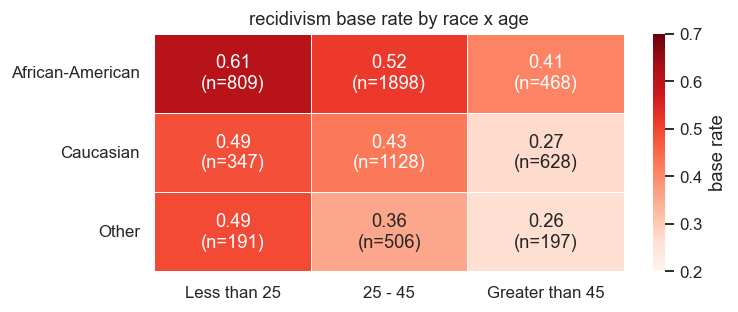

In [10]:
# heatmap of race x age base rates, with the counts
rate = df.pivot_table(index="race_for_model", columns="age_cat",
                      values="two_year_recid", aggfunc="mean")
cnt = df.pivot_table(index="race_for_model", columns="age_cat",
                     values="two_year_recid", aggfunc="size")

order = ["Less than 25", "25 - 45", "Greater than 45"]
rate = rate[order]
cnt = cnt[order]

labels = (rate.round(2).astype(str) + "\n(n=" + cnt.astype(int).astype(str) + ")")

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(rate, annot=labels, fmt="", cmap="Reds", vmin=0.2, vmax=0.7,
            linewidths=0.5, ax=ax, cbar_kws={"label": "base rate"})
ax.set_title("recidivism base rate by race x age")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Part 3: Are the features distributed differently across groups?

This is reason (2) from the intro. If African-American defendants have more priors on average,
then a model that only uses priors will predict a higher risk for them on average, with no racial
term anywhere in the model. The disparity would be inherited from the feature distribution, not
invented by the model.

In [11]:
# mean of each feature within each racial group, plus the overall mean
feat_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count",
             "juv_other_count", "len_of_stay"]

by_race = df.groupby("race_for_model")[feat_cols].mean().round(2)
by_race.loc["ALL"] = df[feat_cols].mean().round(2)
print(by_race.to_string())

                    age  priors_count  juv_fel_count  juv_misd_count  juv_other_count  len_of_stay
race_for_model                                                                                    
African-American  32.43          4.24           0.09            0.14             0.13        17.34
Caucasian         37.49          2.29           0.03            0.04             0.10        11.78
Other             35.04          1.98           0.05            0.05             0.06        11.68
ALL               34.53          3.25           0.06            0.09             0.11        14.62


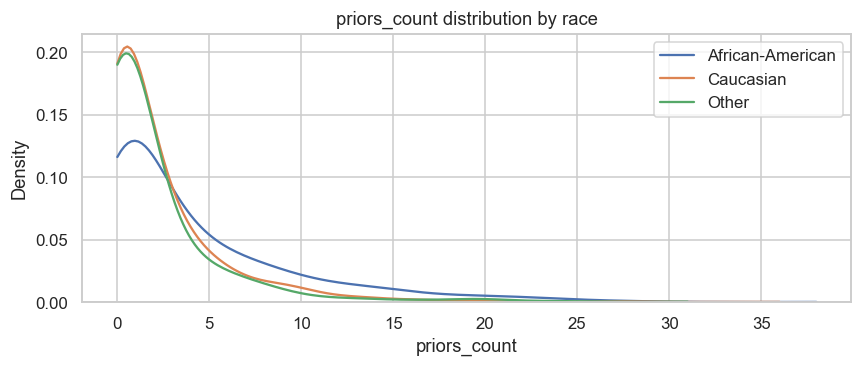

                   count  mean   std  min  25%  50%  75%   max
race_for_model                                                
African-American  3175.0  4.24  5.44  0.0  0.0  2.0  6.0  38.0
Caucasian         2103.0  2.29  3.57  0.0  0.0  1.0  3.0  36.0
Other              894.0  1.98  3.62  0.0  0.0  1.0  2.0  31.0


In [12]:
# priors_count is the single most important feature
# full distribution by race

fig, ax = plt.subplots(figsize=(8, 3.5))
for race, color in zip(["African-American", "Caucasian", "Other"],
                       ["#4C72B0", "#DD8452", "#55A868"]):
    sub = df[df["race_for_model"] == race]["priors_count"]
    sns.kdeplot(sub, label=race, ax=ax, color=color, bw_adjust=1.5, cut=0)
ax.set_title("priors_count distribution by race")
ax.set_xlabel("priors_count")
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby("race_for_model")["priors_count"].describe().round(2).to_string())

So the feature distributions really are different. The African-American group has noticeably more
priors and is younger on average. Both of those push predicted risk up on their own.

Need to compare groups at the same feature values.


## Part 4: Does the same feature point the same way in every group?

This is reason (3). I want to know whether the relationship between a feature
and the outcome is the same shape in every group. If more priors means more recidivism for one
group and less recidivism for another, then no single model can be right about both, and the whole
"fit a model per subpopulation" idea hasmerit.

Two ways to look at it:
- correlation of each feature with the label, computed within each group
- the empirical recidivism rate as a function of binned priors, within each group

In [13]:
# within-group pearson correlation of each feature with the outcome

def corr_table(df, group_col, feat_cols, min_n=100):
    rows = {}
    for g, sub in df.groupby(group_col):
        if len(sub) < min_n:
            continue
        rows[f"{g} (n={len(sub)})"] = {
            f: sub[f].corr(sub["two_year_recid"]) for f in feat_cols
        }
    out = pd.DataFrame(rows)
    out["ALL"] = [df[f].corr(df["two_year_recid"]) for f in feat_cols]
    return out.round(3)

ct = corr_table(df, "race_for_model", feat_cols)
print("correlation with two_year_recid, computed within each racial group")
print(ct.to_string())

correlation with two_year_recid, computed within each racial group
                 African-American (n=3175)  Caucasian (n=2103)  Other (n=894)    ALL
age                                 -0.155              -0.188         -0.175 -0.189
priors_count                         0.275               0.268          0.279  0.291
juv_fel_count                        0.089               0.056          0.072  0.082
juv_misd_count                       0.110               0.079          0.111  0.110
juv_other_count                      0.161               0.070          0.073  0.126
len_of_stay                          0.099               0.113          0.102  0.109


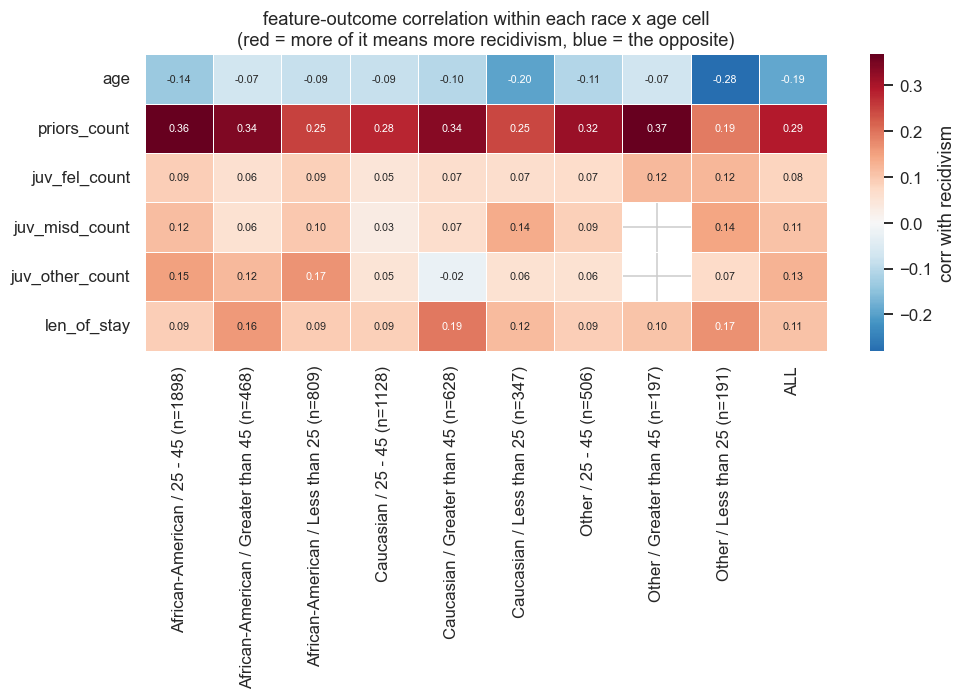

In [14]:
# same but for the 9 race x age cells, where things are more likely to break down

df["race_age"] = df["race_for_model"] + " / " + df["age_cat"]
ct2 = corr_table(df, "race_age", feat_cols, min_n=100)

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(ct2, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            linewidths=0.5, ax=ax, annot_kws={"size": 7},
            cbar_kws={"label": "corr with recidivism"})
ax.set_title("feature-outcome correlation within each race x age cell\n(red = more of it means more recidivism, blue = the opposite)")
plt.tight_layout()
plt.show()

A row that is red in some columns and blue in others is a feature whose direction depends on the group. 
Every feature's raw correlation with recidivism points the same direction in all nine race x age cells. The one exception, 
juv_other_count at -0.02, is a group where almost nobody has a nonzero value.

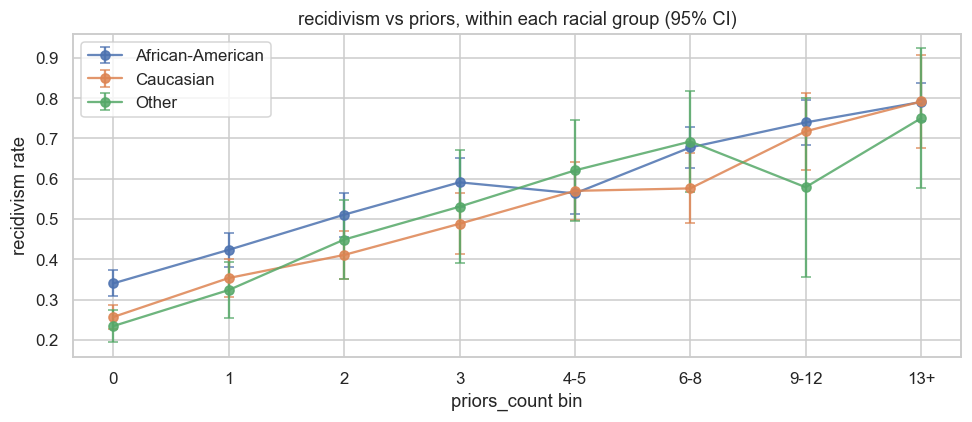

In [15]:
# recidivism rate vs priors, per race. error bars are 95% binomial CI

bins = [-0.1, 0, 1, 2, 3, 5, 8, 12, 100]
labels = ["0", "1", "2", "3", "4-5", "6-8", "9-12", "13+"]
df["priors_bin"] = pd.cut(df["priors_count"], bins=bins, labels=labels)

rate = df.pivot_table(index="priors_bin", columns="race_for_model",
                      values="two_year_recid", aggfunc="mean", observed=True)
cnt = df.pivot_table(index="priors_bin", columns="race_for_model",
                     values="two_year_recid", aggfunc="size", observed=True)
se = np.sqrt(rate * (1 - rate) / cnt)
rate = rate.mask(cnt < 15)   # blank small cells but keep the row so x positions stay aligned

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(labels))
for race, color in zip(["African-American", "Caucasian", "Other"],
                       ["#4C72B0", "#DD8452", "#55A868"]):
    ax.errorbar(x, rate[race], yerr=1.96 * se[race], fmt="o-", color=color,
                label=race, capsize=3, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("priors_count bin"); ax.set_ylabel("recidivism rate")
ax.set_title("recidivism vs priors, within each racial group (95% CI)")
ax.legend()
plt.tight_layout()
plt.show()

All three curves increase, and they sit about 7 to 10 points apart. The groups differ in level, not in slope. A single model with a group intercept would absorb that.

## Part 5: Simpson's paradox

Version A (base rates). Group A has a higher rate than group B overall, but a lower rate than
group B inside every single level of some third variable. This is a statement about the data only,
no model involved. It happens when the third variable is unequally distributed across groups

Version B (slopes). The pooled regression coefficient for a feature has one sign, but the
within-group coefficient has the other sign. This is the "coefficient flip"

I check A here

In [16]:
def simpsons_base_rates(df, group_col, cond_col, min_cell=30):
    "check whether the sign of the base rate gap between two groups flips inside levels of cond_col"
    groups = sorted(df[group_col].dropna().unique())
    findings = []

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            r1 = df[df[group_col] == g1]["two_year_recid"].mean()
            r2 = df[df[group_col] == g2]["two_year_recid"].mean()
            overall_gap = r1 - r2

            flips = []
            for lvl, sub in df.groupby(cond_col, observed=True):
                s1 = sub[sub[group_col] == g1]
                s2 = sub[sub[group_col] == g2]
                if len(s1) < min_cell or len(s2) < min_cell:
                    continue
                gap = s1["two_year_recid"].mean() - s2["two_year_recid"].mean()
                # a flip means the within-level gap points the other way and is not tiny
                if np.sign(gap) != np.sign(overall_gap) and abs(gap) > 0.02:
                    flips.append((lvl, round(gap, 3)))

            findings.append({
                "comparison": f"{g1} vs {g2}",
                "conditioned_on": cond_col,
                "overall_gap": round(overall_gap, 3),
                "n_flipped_levels": len(flips),
                "flipped_levels": flips,
            })
    return pd.DataFrame(findings)


checks = pd.concat([
    simpsons_base_rates(df, "race_for_model", "age_cat"),
    simpsons_base_rates(df, "race_for_model", "priors_bin"),
    simpsons_base_rates(df, "sex", "age_cat"),
    simpsons_base_rates(df, "sex", "priors_bin"),
], ignore_index=True)

print(checks.to_string(index=False))

                   comparison conditioned_on  overall_gap  n_flipped_levels                                           flipped_levels
African-American vs Caucasian        age_cat        0.132                 0                                                       []
    African-American vs Other        age_cat        0.158                 0                                                       []
           Caucasian vs Other        age_cat        0.026                 0                                                       []
African-American vs Caucasian     priors_bin        0.132                 0                                                       []
    African-American vs Other     priors_bin        0.158                 1                                          [(4-5, -0.057)]
           Caucasian vs Other     priors_bin        0.026                 4 [(2, -0.038), (3, -0.042), (4-5, -0.051), (6-8, -0.116)]
               Female vs Male        age_cat       -0.128            

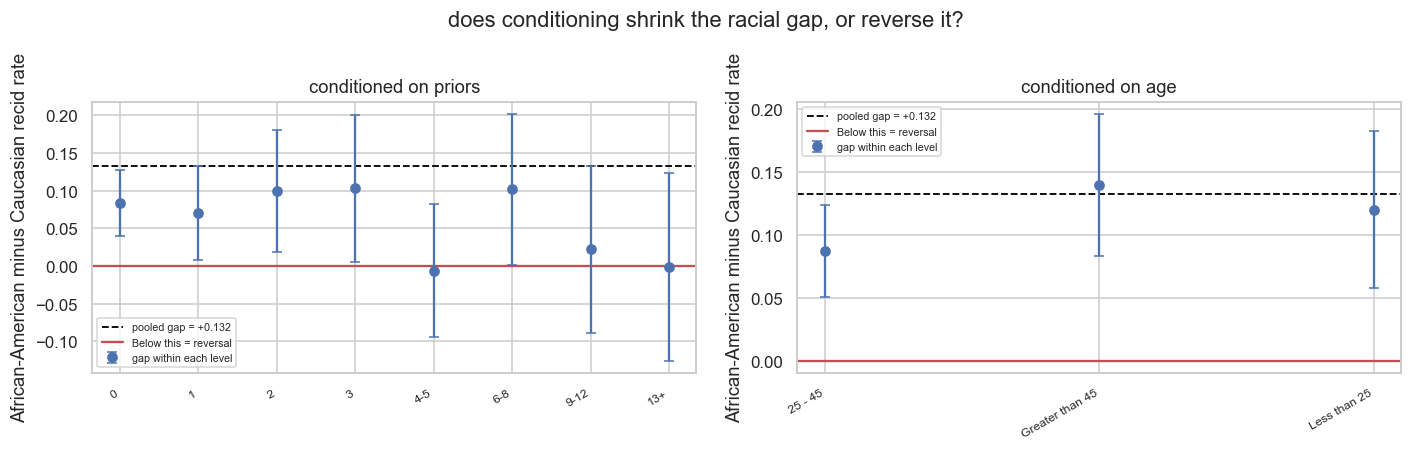

In [17]:
# Simpson's check: is the racial gap reversed inside subgroups, or just shrunk?
#   dots below the black line = the gap shrinks when you condition (confounding)
#   dots below zero           = the gap reverses (Simpson's paradox)

pairs = [("priors_bin", "priors"), ("age_cat", "age")]
g1, g2 = "African-American", "Caucasian"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (ccol, nice) in zip(axes, pairs):
    pooled = (df[df.race_for_model == g1]["two_year_recid"].mean()
              - df[df.race_for_model == g2]["two_year_recid"].mean())

    lvls, gaps, errs = [], [], []
    for lvl, sub in df.groupby(ccol, observed=True):
        a = sub[sub.race_for_model == g1]["two_year_recid"]
        c = sub[sub.race_for_model == g2]["two_year_recid"]
        if len(a) < 30 or len(c) < 30:
            continue
        lvls.append(str(lvl))
        gaps.append(a.mean() - c.mean())
        # standard error of a difference in two proportions
        errs.append(1.96 * np.sqrt(a.mean()*(1-a.mean())/len(a) + c.mean()*(1-c.mean())/len(c)))

    ax.errorbar(range(len(gaps)), gaps, yerr=errs, fmt="o", color="#4C72B0",
                capsize=3, zorder=3, label="gap within each level")
    ax.axhline(pooled, color="black", ls="--", lw=1.2, label=f"pooled gap = {pooled:+.3f}")
    ax.axhline(0, color="#C44E52", lw=1.5, label="Below this = reversal")
    ax.set_xticks(range(len(lvls)))
    ax.set_xticklabels(lvls, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(f"{g1} minus {g2} recid rate")
    ax.set_title(f"conditioned on {nice}")
    ax.legend(fontsize=7)

plt.suptitle("does conditioning shrink the racial gap, or reverse it?", y=1.02)
plt.tight_layout()
plt.show()

Conditioning on priors shrinks the Black-White gap toward zero at high priors levels but never reverses it. 
Among defendants with many priors, race carries no additional information about recidivism. The racial gap lives almost entirely in the low-priors population.
That is confounding, not Simpson's paradox. Conditioning on age barely changes the gap at all, so age is not what's driving it. Priors is.

## Part 6: one global model, and how it does per group

Fit one logistic regression on everybody, with no race or age category as
input, and then look at how it performs inside each group. The point is to find out what kind of
unfairness a global model produces here.

The metrics, per group:
- AUC: can the model rank people in this group correctly? This is threshold free.
- FPR / FNR: at the standard 0.5 threshold, who gets wrongly flagged and who gets missed.
- calibration: is the average predicted probability equal to the actual rate in this group?

The reason to separate AUC from FPR/FNR is that they answer different questions. If AUC is similar
across groups but FPR/FNR are not, the model is ranking fine and the disparity is coming from the
single shared threshold interacting with different base rates. If AUC itself is worse for a group,
then the model genuinely understands that group less well, which is the thing that would justify a
separate model.

In [18]:
# build the feature matrix. deliberately no race and no age_cat, so any disparity below is
# something the model produced from the other features rather than being told directly

df["sex_male"] = (df["sex"] == "Male").astype(int)
df["charge_felony"] = (df["c_charge_degree"] == "F").astype(int)

MODEL_FEATURES = ["age", "priors_count", "juv_fel_count", "juv_misd_count",
                  "juv_other_count", "len_of_stay", "days_b_screening_arrest",
                  "sex_male", "charge_felony"]

X = df[MODEL_FEATURES].copy()
y = df["two_year_recid"].copy()

# demographics kept aside so I can slice results by them later

sens = df[["race_for_model", "sex", "age_cat", "race_age", "priors_bin"]].copy()

X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(
    X, y, sens, test_size=0.3, random_state=SEED, stratify=y
)

print("train:", X_tr.shape[0], " test:", X_te.shape[0])
print("train base rate:", round(y_tr.mean(), 3), " test base rate:", round(y_te.mean(), 3))
print("features:", MODEL_FEATURES)

train: 4320  test: 1852
train base rate: 0.455  test base rate: 0.455
features: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'len_of_stay', 'days_b_screening_arrest', 'sex_male', 'charge_felony']


In [19]:
# one global logistic regression. scaling is inside the pipeline so the coefficients are
# comparable to each other later

global_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)
)
global_model.fit(X_tr, y_tr)

p_global = global_model.predict_proba(X_te)[:, 1]
yhat_global = (p_global >= 0.5).astype(int)

print("global model, held out test set")
print("  accuracy :", round(accuracy_score(y_te, yhat_global), 4))
print("  AUC      :", round(roc_auc_score(y_te, p_global), 4))
print("  log loss :", round(log_loss(y_te, p_global), 4))
print("  brier    :", round(brier_score_loss(y_te, p_global), 4))
print()
print("Baseline if we predicted the majority class:",
      round(max(y_te.mean(), 1 - y_te.mean()), 4))

global model, held out test set
  accuracy : 0.6895
  AUC      : 0.7338
  log loss : 0.6072
  brier    : 0.2087

Baseline if we predicted the majority class: 0.5448


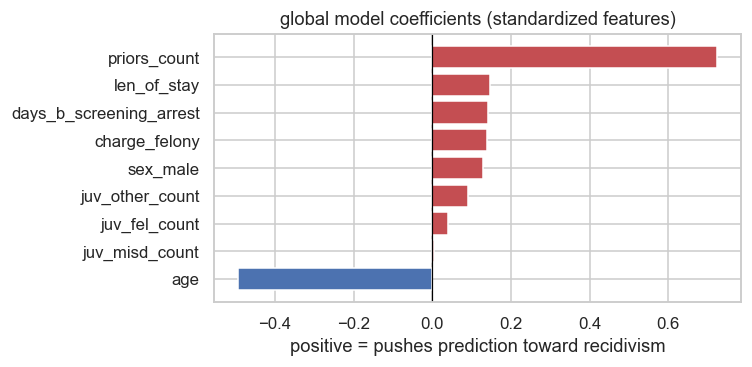

age                       -0.493
juv_misd_count             0.005
juv_fel_count              0.040
juv_other_count            0.091
sex_male                   0.129
charge_felony              0.140
days_b_screening_arrest    0.142
len_of_stay                0.147
priors_count               0.725


In [20]:
# the coefficients with global model

coefs = pd.Series(
    global_model.named_steps["logisticregression"].coef_[0],
    index=MODEL_FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coefs]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("global model coefficients (standardized features)")
ax.set_xlabel("positive = pushes prediction toward recidivism")
plt.tight_layout()
plt.show()

print(coefs.round(3).to_string())

In [21]:
def per_group_metrics(y_true, y_prob, group_labels, threshold=0.5, min_n=30):
    "accuracy / FPR / FNR / AUC / calibration for the global model inside each group"
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    group_labels = np.asarray(group_labels)

    rows = []
    for g in sorted(pd.unique(group_labels)):
        m = group_labels == g
        n = m.sum()
        if n < min_n:
            continue
        yt, yp, pr = y_true[m], y_pred[m], y_prob[m]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({
            "group": g,
            "n": int(n),
            "base_rate": yt.mean(),
            # can the model rank inside this group? needs both classes present
            "AUC": roc_auc_score(yt, pr) if len(np.unique(yt)) > 1 else np.nan,
            "accuracy": accuracy_score(yt, yp),
            "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) else np.nan,
            "pred_pos_rate": yp.mean(),
            "mean_pred_prob": pr.mean(),
            # calibration gap: if this is near zero the model is right on average for this group
            "calib_gap": pr.mean() - yt.mean(),
        })
    return pd.DataFrame(rows).round(3)


print("global model, sliced by race")
print(per_group_metrics(y_te, p_global, s_te["race_for_model"]).to_string(index=False))
print()
print("global model, sliced by sex")
print(per_group_metrics(y_te, p_global, s_te["sex"]).to_string(index=False))
print()
print("global model, sliced by age category")
print(per_group_metrics(y_te, p_global, s_te["age_cat"]).to_string(index=False))

global model, sliced by race
           group   n  base_rate   AUC  accuracy   FPR   FNR  pred_pos_rate  mean_pred_prob  calib_gap
African-American 956      0.535 0.738     0.688 0.283 0.337          0.486           0.517     -0.018
       Caucasian 645      0.372 0.687     0.685 0.123 0.638          0.212           0.379      0.007
           Other 251      0.367 0.727     0.705 0.126 0.587          0.231           0.405      0.039

global model, sliced by sex
 group    n  base_rate   AUC  accuracy   FPR   FNR  pred_pos_rate  mean_pred_prob  calib_gap
Female  360      0.353 0.709     0.725 0.047 0.693          0.139           0.339     -0.014
  Male 1492      0.480 0.730     0.681 0.238 0.406          0.409           0.481      0.001

global model, sliced by age category
          group    n  base_rate   AUC  accuracy   FPR   FNR  pred_pos_rate  mean_pred_prob  calib_gap
        25 - 45 1027      0.468 0.715     0.674 0.211 0.457          0.366           0.486      0.018
Greater than 

- The AUC is similar across racial groups: about 0.74, 0.69 and 0.73. Caucasian is a bit lower
  but they are in the same ballpark. The model ranks people inside each group about equally well (gives the reoffender the higher score/probability)
- The FPR and FNR are different: FPR is 0.28 for African-American defendants and 0.12 for
  Caucasian defendants, while FNR runs the other way, 0.34 versus 0.64. This is the ProPublica
  finding, and it reproduces even though race is not a feature.
- The calibration gap is small in each group (within about 0.04)

So the model is roughly equally good at ranking and roughly calibrated, but produces very unequal
error rates. The unfairness here is coming from the base rate
difference plus one shared threshold, not from the model being worse at understanding one group.

Which means that threshold adjustment could fix the FPR/FNR gap. Fitting a whole separate model per
group would not obviously help, because the ranking is already fine

In [22]:
# same table but for the 9 race x age cells

per_cell = per_group_metrics(y_te, p_global, s_te["race_age"], min_n=40)
print(per_cell.sort_values("AUC").to_string(index=False))

                             group   n  base_rate   AUC  accuracy   FPR   FNR  pred_pos_rate  mean_pred_prob  calib_gap
               Caucasian / 25 - 45 316      0.389 0.614     0.633 0.155 0.699          0.212           0.416      0.027
           Other / Greater than 45  47      0.213 0.664     0.787 0.054 0.800          0.085           0.252      0.039
   African-American / Less than 25 240      0.612 0.665     0.650 0.409 0.313          0.579           0.527     -0.086
                   Other / 25 - 45 143      0.371 0.692     0.678 0.111 0.679          0.189           0.418      0.047
          Caucasian / Less than 25 121      0.512 0.697     0.686 0.288 0.339          0.479           0.514      0.002
       Caucasian / Greater than 45 208      0.264 0.699     0.764 0.020 0.836          0.058           0.245     -0.019
        African-American / 25 - 45 568      0.537 0.744     0.695 0.285 0.321          0.496           0.542      0.005
African-American / Greater than 45 148  

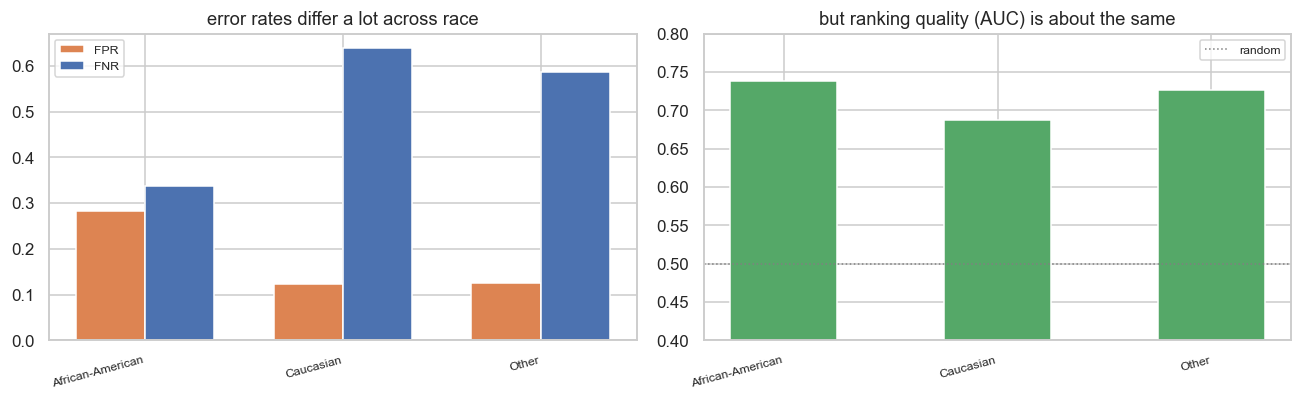

In [23]:
# is the AUC gap or the FPR/FNR gap the bigger problem?

m_race = per_group_metrics(y_te, p_global, s_te["race_for_model"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

x = np.arange(len(m_race))
w = 0.35
axes[0].bar(x - w / 2, m_race["FPR"], w, label="FPR", color="#DD8452")
axes[0].bar(x + w / 2, m_race["FNR"], w, label="FNR", color="#4C72B0")
axes[0].set_xticks(x)
axes[0].set_xticklabels(m_race["group"], rotation=15, ha="right", fontsize=8)
axes[0].set_title("error rates differ a lot across race")
axes[0].legend(fontsize=8)

axes[1].bar(x, m_race["AUC"], 0.5, color="#55A868")
axes[1].axhline(0.5, color="gray", ls=":", lw=1, label="random")
axes[1].set_ylim(0.4, 0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(m_race["group"], rotation=15, ha="right", fontsize=8)
axes[1].set_title("but ranking quality (AUC) is about the same")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

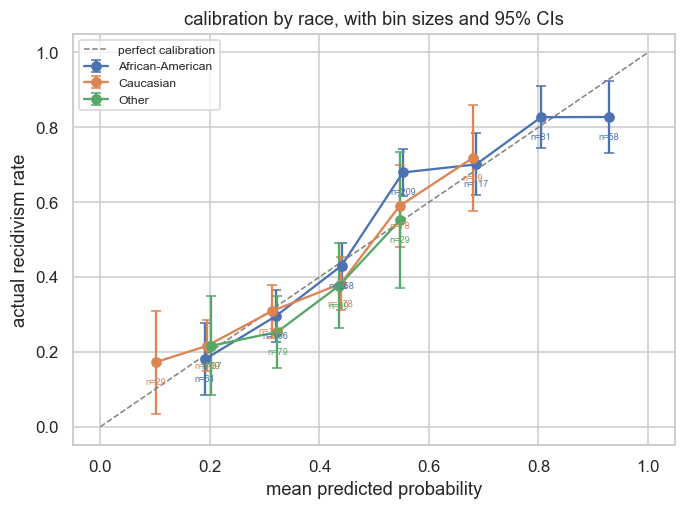

In [24]:
# calibration curve per racial group, with 95% binomial CIs and bin sizes
# reading it: if the model gave a group of people roughly a 0.55 chance of reoffending, did about
# 55% of them actually reoffend? if yes, the dot lands on the diagonal
for race, color in zip(["African-American", "Caucasian", "Other"], ["#4C72B0", "#DD8452", "#55A868"]):
    m = (s_te["race_for_model"] == race).values
    pr, yt = p_global[m], y_te.values[m]
    idx = np.digitize(pr, np.linspace(0, 1, 9)) - 1
    xs, ys, ns = [], [], []
    for b in range(8):
        sel = idx == b
        if sel.sum() < 20:
            continue
        xs.append(pr[sel].mean()); ys.append(yt[sel].mean()); ns.append(sel.sum())
    err = [1.96 * np.sqrt(p * (1 - p) / n) for p, n in zip(ys, ns)]
    plt.errorbar(xs, ys, yerr=err, fmt="o-", color=color, label=race, capsize=3)
    for x, y, n in zip(xs, ys, ns):
        plt.text(x, y - 0.06, f"n={n}", fontsize=6, ha="center", color=color)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="perfect calibration")
plt.xlabel("mean predicted probability"); plt.ylabel("actual recidivism rate")
plt.title("calibration by race, with bin sizes and 95% CIs")
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [25]:
# mean calibration gap (mean(predicted) - mean(actual)) hides range-dependent miscalibration: over-predict in one band and
# under-predict in another and the average looks perfect. so test across the range too

from scipy.stats import chi2
for race in ["African-American", "Caucasian", "Other"]:
    m = (s_te["race_for_model"] == race).values
    pr, yt = p_global[m], y_te.values[m]
    q = pd.qcut(pr, 10, labels=False, duplicates="drop")
    H = sum((yt[q == b].sum() - pr[q == b].sum()) ** 2 /
            (pr[q == b].sum() * (1 - pr[q == b].sum() / (q == b).sum()))
            for b in np.unique(q) if 0 < pr[q == b].sum() < (q == b).sum())
    # df convention: (bins - 2) is for a model evaluated on the data it was FIT on.
    # this is a held-out test set, where the standard is df = bins. report the honest one,
    # keep the in-sample one visible since an earlier version used it.
    ddf_val = len(np.unique(q))
    ddf_dev = len(np.unique(q)) - 2
    print(f"{race:18s} mean gap={pr.mean()-yt.mean():+.3f}   "
          f"Hosmer-Lemeshow p={chi2.sf(H, ddf_val):.3f}  "
          f"(in-sample convention would give p={chi2.sf(H, ddf_dev):.3f})")

African-American   mean gap=-0.018   Hosmer-Lemeshow p=0.076  (in-sample convention would give p=0.031)
Caucasian          mean gap=+0.007   Hosmer-Lemeshow p=0.637  (in-sample convention would give p=0.442)
Other              mean gap=+0.039   Hosmer-Lemeshow p=0.279  (in-sample convention would give p=0.147)


The mean calibration gap is tiny for every racial group, and smallest of all for African-American defendants (-0.018).
The Hosmer-Lemeshow test, which compares predicted to actual within risk deciles instead of averaging over them,
comes out borderline for African-American defendants (p = 0.076 under the held-out-data convention df = bins;
the in-sample convention df = bins - 2 would say p = 0.031) and clearly fine for the other two groups.
The robust statement is band-level, not test-level: the model under-predicts risk for African-American defendants
by about 12.7 points in the 0.50-0.625 band (n = 209, CI excludes the diagonal) and over-predicts at the very top,
and the two errors cancel in the mean gap. So calibrated on average, mildly miscalibrated
across the range

## Part 6.5: two consequences of Part 6, checked directly

1. Per-group thresholds should close most of the FPR/FNR gap. If the ranking is fine and only the
   shared threshold is wrong per group, no constrained optimization is needed: pick each group's
   threshold on the training set so its training FPR matches the global one, and the test gaps
   should shrink.
2. The threshold's worst interactions should be along priors, not race. Base rates vary far more
   across priors bins than across races, so a single 0.5 threshold should produce far more extreme
   FPR/FNR swings along priors -- and the racial gap should look like a milder, inherited version of it.

target FPR (global model on train): 0.212
per-group thresholds: {'African-American': 0.539, 'Caucasian': 0.458, 'Other': 0.467}

            race  threshold   FPR   FNR  accuracy
African-American shared 0.5 0.283 0.337     0.688
African-American  per-group 0.207 0.438     0.669
       Caucasian shared 0.5 0.123 0.638     0.685
       Caucasian  per-group 0.222 0.533     0.662
           Other shared 0.5 0.126 0.587     0.705
           Other  per-group 0.182 0.467     0.713

overall accuracy: shared 0.5 = 0.6895   per-group = 0.6728


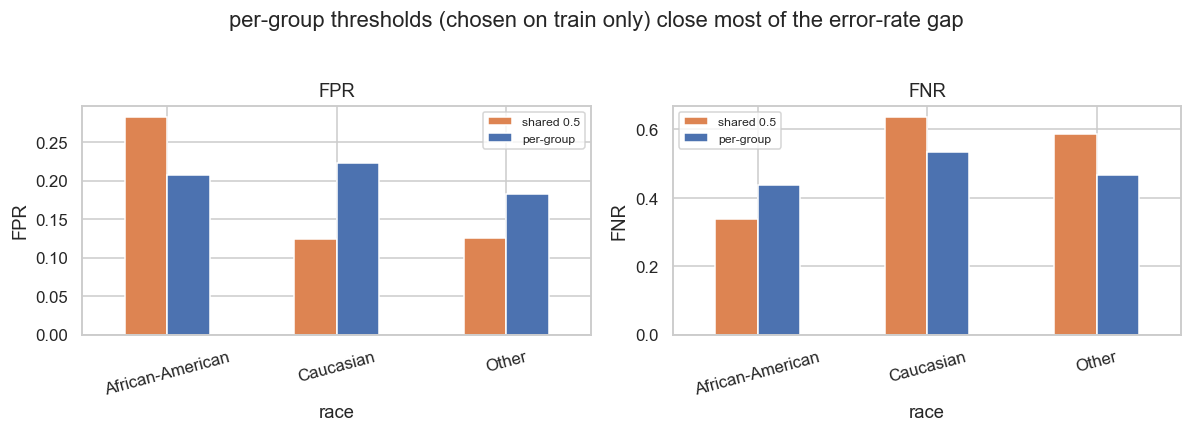

In [26]:
# 1) per-group thresholds, chosen on the training set to match the global model's own train FPR

p_train = global_model.predict_proba(X_tr)[:, 1]

def fpr_at(y_true, y_prob, t):
    yp = (y_prob >= t).astype(int)
    return ((yp == 1) & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)

target_fpr = fpr_at(y_tr.values, p_train, 0.5)

thresholds = {}
for race in ["African-American", "Caucasian", "Other"]:
    m = (s_tr["race_for_model"] == race).values
    cand = np.unique(np.round(p_train[m], 3))
    fprs = np.array([fpr_at(y_tr.values[m], p_train[m], t) for t in cand])
    thresholds[race] = float(cand[np.argmin(np.abs(fprs - target_fpr))])

print("target FPR (global model on train):", round(target_fpr, 3))
print("per-group thresholds:", {k: round(v, 3) for k, v in thresholds.items()})
print()

rows = []
for race in ["African-American", "Caucasian", "Other"]:
    m = (s_te["race_for_model"] == race).values
    yt, pr = y_te.values[m], p_global[m]
    for label, t in [("shared 0.5", 0.5), ("per-group", thresholds[race])]:
        yp = (pr >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({"race": race, "threshold": label,
                     "FPR": fp / (fp + tn), "FNR": fn / (fn + tp),
                     "accuracy": accuracy_score(yt, yp)})
thr = pd.DataFrame(rows)
print(thr.round(3).to_string(index=False))

acc_shared = accuracy_score(y_te, (p_global >= 0.5).astype(int))
yp_grp = np.zeros(len(y_te), dtype=int)
for race, t in thresholds.items():
    m = (s_te["race_for_model"] == race).values
    yp_grp[m] = (p_global[m] >= t).astype(int)
print(f"\noverall accuracy: shared 0.5 = {acc_shared:.4f}   per-group = {accuracy_score(y_te, yp_grp):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, metric in zip(axes, ["FPR", "FNR"]):
    piv = thr.pivot(index="race", columns="threshold", values=metric)[["shared 0.5", "per-group"]]
    piv.plot.bar(ax=ax, color=["#DD8452", "#4C72B0"], rot=15)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
plt.suptitle("per-group thresholds (chosen on train only) close most of the error-rate gap", y=1.03)
plt.tight_layout()
plt.show()

group   n  base_rate   AUC  accuracy   FPR   FNR  pred_pos_rate  mean_pred_prob  calib_gap
    0 652      0.298 0.681     0.733 0.044 0.794          0.092           0.339      0.042
    1 335      0.346 0.648     0.690 0.128 0.655          0.203           0.384      0.038
    2 198      0.485 0.641     0.566 0.225 0.656          0.283           0.419     -0.066
    3 139      0.561 0.676     0.655 0.246 0.423          0.432           0.464     -0.097
  4-5 153      0.569 0.656     0.595 0.470 0.356          0.569           0.509     -0.060
  6-8 155      0.665 0.623     0.684 0.596 0.175          0.748           0.583     -0.082
 9-12 105      0.724 0.596     0.714 0.897 0.053          0.933           0.715     -0.009
  13+ 115      0.809 0.533     0.809 1.000 0.000          1.000           0.869      0.060


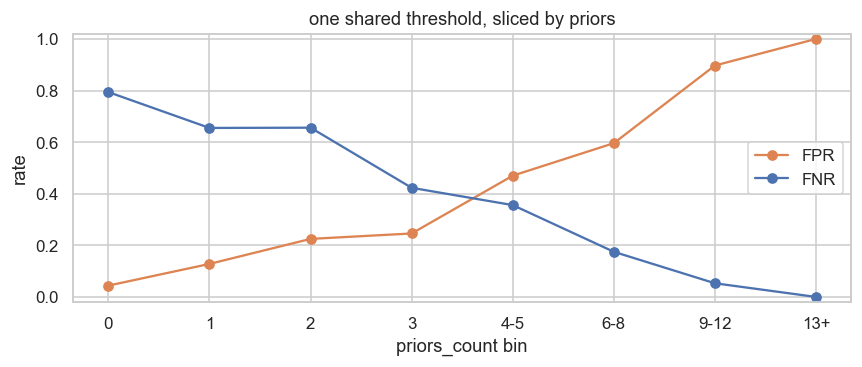

In [27]:
# 2) the same global model at the same 0.5 threshold, sliced along priors instead of race

per_priors = per_group_metrics(y_te, p_global, s_te["priors_bin"], min_n=30)
order = ["0", "1", "2", "3", "4-5", "6-8", "9-12", "13+"]
per_priors = per_priors.set_index("group").reindex(order).dropna(how="all").reset_index()
print(per_priors.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(per_priors["group"], per_priors["FPR"], "o-", color="#DD8452", label="FPR")
ax.plot(per_priors["group"], per_priors["FNR"], "o-", color="#4C72B0", label="FNR")
ax.set_xlabel("priors_count bin"); ax.set_ylabel("rate"); ax.set_ylim(-0.02, 1.02)
ax.set_title("one shared threshold, sliced by priors")
ax.legend()
plt.tight_layout()
plt.show()

Both predictions hold.

- Per-group thresholds work. Test FPR moves from 0.28 / 0.12 / 0.13 to roughly 0.21 / 0.22 / 0.18,
  and FNR from 0.34 / 0.64 / 0.59 to roughly 0.44 / 0.53 / 0.47, at a cost of about 1.7 points of
  overall accuracy. The residual gap is what the calibration-vs-equalized-odds impossibility says
  cannot be removed while staying calibrated.
- The real axis is priors. Sliced by priors bin, the shared threshold is far more extreme than
  anything seen by race: FPR climbs from 0.04 (no priors) to 1.00 (13+ priors) while FNR falls from
  0.79 to 0.00. At 0.5 the model effectively decides "many priors = flagged, few priors = not
  flagged". The racial FPR/FNR gap is mostly this priors effect showing up in groups with different
  priors distributions, consistent with Part 3.

## Part 7: With one model per group, do the coefficients flip?

Now version B of Simpson's paradox, we fit a separate logistic regression on each subgroup and
compare the coefficients to the global ones. If a feature has a positive coefficient in one group
and a negative one in another, then the two groups disagree about what the feature means, and no
single linear model can represent both.

Note: Standardize using each group's own scaler, so the coefficients are on a
comparable scale. No group with fewer than 100 people is fit

In [28]:
def fit_per_group(X, y, groups, features, min_n=100, C=1.0):
    # fit one standardized logistic regression per group.
    # returns {group: coefficient series}, {group: fitted pipeline}, {group: n}
    coefs, models, sizes = {}, {}, {}
    for g in sorted(pd.unique(groups)):
        m = (groups == g).values
        n = m.sum()
        if n < min_n:
            print(f"  skipping {g:35s} n={n:4d} (too small)")
            continue
        if y[m].nunique() < 2:
            print(f"  skipping {g:35s} n={n:4d} (only one class present)")
            continue

        pipe = make_pipeline(StandardScaler(),
                             LogisticRegression(C=C, max_iter=2000, random_state=SEED))
        pipe.fit(X[m], y[m])
        coefs[g] = pd.Series(pipe.named_steps["logisticregression"].coef_[0], index=features)
        models[g] = pipe
        sizes[g] = int(n)
    return coefs, models, sizes


print("fitting one model per race x age cell, on the training set only")
g_tr = s_tr["race_age"]
g_te = s_te["race_age"]
cell_coefs, cell_models, cell_sizes = fit_per_group(X_tr, y_tr, g_tr, MODEL_FEATURES, min_n=100)
print()
print("fitted", len(cell_coefs), "group models")

fitting one model per race x age cell, on the training set only

fitted 9 group models


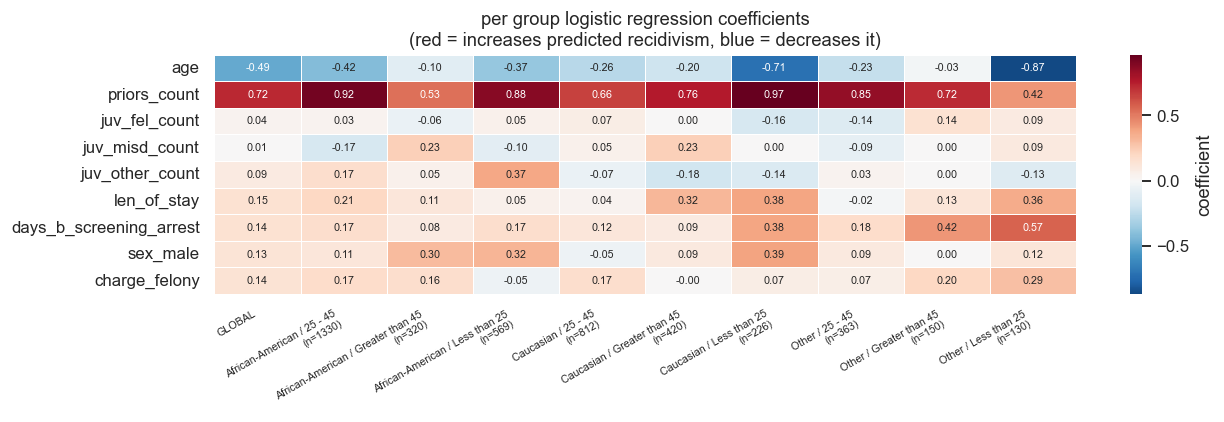

In [29]:
# put all the coefficients side by side, with the global model as the reference column
coef_table = pd.DataFrame(cell_coefs)
coef_table.insert(0, "GLOBAL", coefs)   # 'coefs' is the global model series from part 6

# label columns with their sample size so I never forget how thin some of these are
coef_table.columns = ["GLOBAL"] + [f"{c}\n(n={cell_sizes[c]})" for c in coef_table.columns[1:]]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(coef_table, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            linewidths=0.5, ax=ax, annot_kws={"size": 7},
            cbar_kws={"label": "coefficient"})
ax.set_title("per group logistic regression coefficients\n(red = increases predicted recidivism, blue = decreases it)")
plt.xticks(rotation=30, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

A logistic regression coefficient only means something if the feature actually varies inside the
group. The juvenile counts are over 92% zeros overall. In a small group they can easily be zero for
literally everyone, and then the fitted coefficient is either exactly 0 or is being set by one or two
individuals.

In [30]:
# support check: how many nonzero observations does each feature have inside each group?
# a coefficient fit on a feature with 0 or 1 nonzero values is meaningless

support = {}
for g in cell_coefs.keys():
    m = (g_tr == g).values
    support[g] = {f: int((X_tr[m][f] != 0).sum()) for f in MODEL_FEATURES}
support = pd.DataFrame(support)

print("number of nonzero values per feature, per group (training set)")
print(support.to_string())
print()

# only matters if the feature has at least 20 nonzero values in that group

MIN_SUPPORT = 20
low = (support < MIN_SUPPORT)
print(f"feature/group pairs with fewer than {MIN_SUPPORT} nonzero values (coefficient not trustworthy):")
for f in MODEL_FEATURES:
    bad = low.loc[f]
    if bad.any():
        print(f"  {f:24s} -> {', '.join(f'{g} ({support.loc[f, g]})' for g in bad[bad].index)}")

number of nonzero values per feature, per group (training set)
                         African-American / 25 - 45  African-American / Greater than 45  African-American / Less than 25  Caucasian / 25 - 45  Caucasian / Greater than 45  Caucasian / Less than 25  Other / 25 - 45  Other / Greater than 45  Other / Less than 25
age                                            1330                                 320                              569                  812                          420                       226              363                      150                   130
priors_count                                   1044                                 251                              330                  528                          255                       124              210                       83                    62
juv_fel_count                                    80                                   7                               36                    8             

The juvenile count features have almost no support in the older and smaller cells. Any
"flip" involving those cells is going to be about one or two people.

In [31]:
# naive flip detection: a feature "flips" if some group has a clearly positive coefficient and
# another has a clearly negative one. threshold of 0.1 so near zero noise does not count

THRESH = 0.1
group_cols = list(cell_coefs.keys())
raw_coefs = pd.DataFrame(cell_coefs)

print("naive flip detection (threshold =", THRESH, ")")
print("=" * 70)

naive_flips = []
for f in MODEL_FEATURES:
    vals = raw_coefs.loc[f]
    pos = vals[vals > THRESH]
    neg = vals[vals < -THRESH]
    if len(pos) and len(neg):
        naive_flips.append(f)
        print(f"\n{f}   (global coefficient: {coefs[f]:+.3f})")
        print(f"  positive in: {', '.join(f'{g} ({v:+.2f}, n={cell_sizes[g]})' for g, v in pos.items())}")
        print(f"  negative in: {', '.join(f'{g} ({v:+.2f}, n={cell_sizes[g]})' for g, v in neg.items())}")

print()
print("features with a naive flip:", naive_flips)

naive flip detection (threshold = 0.1 )

juv_fel_count   (global coefficient: +0.040)
  positive in: Other / Greater than 45 (+0.14, n=150)
  negative in: Caucasian / Less than 25 (-0.16, n=226), Other / 25 - 45 (-0.14, n=363)

juv_misd_count   (global coefficient: +0.005)
  positive in: African-American / Greater than 45 (+0.23, n=320), Caucasian / Greater than 45 (+0.23, n=420)
  negative in: African-American / 25 - 45 (-0.17, n=1330)

juv_other_count   (global coefficient: +0.091)
  positive in: African-American / 25 - 45 (+0.17, n=1330), African-American / Less than 25 (+0.37, n=569)
  negative in: Caucasian / Greater than 45 (-0.18, n=420), Caucasian / Less than 25 (-0.14, n=226), Other / Less than 25 (-0.13, n=130)

features with a naive flip: ['juv_fel_count', 'juv_misd_count', 'juv_other_count']


So on the face of it there are flips but on small groups

## Part 8: Are the flips real or just noise?

Bootstrap

For each group we resample its training rows with replacement 300 times, refit the
logistic regression, and record the sign of each coefficient each time. If the coefficient is
genuinely positive in that group, it should come out positive in nearly every bootstrap replicate.

We call a flip credible only if:
- there is a group where the coefficient is positive in at least 95% of replicates, AND
- there is another group where it is positive in at most 5% of replicates.

In [32]:
def bootstrap_signs(X, y, groups, features, n_boot=300, min_n=100, seed=SEED):
    # for each group, the fraction of bootstrap replicates where each coefficient is positive.
    # near 1 = confidently positive, near 0 = confidently negative, near 0.5 = sign undetermined.
    rng = np.random.default_rng(seed)
    out = {}

    for g in sorted(pd.unique(groups)):
        m = (groups == g).values
        idx = np.where(m)[0]
        if len(idx) < min_n or y.iloc[idx].nunique() < 2:
            continue

        Xg = X.iloc[idx].values
        yg = y.iloc[idx].values
        pos_count = np.zeros(len(features))
        n_ok = 0

        for _ in range(n_boot):
            take = rng.integers(0, len(idx), len(idx))   # resample with replacement
            yb = yg[take]
            if len(np.unique(yb)) < 2:
                continue
            pipe = make_pipeline(StandardScaler(),
                                 LogisticRegression(C=1.0, max_iter=2000))
            pipe.fit(Xg[take], yb)
            c = pipe.named_steps["logisticregression"].coef_[0]
            pos_count += (c > 0)
            n_ok += 1

        out[g] = pd.Series(pos_count / max(n_ok, 1), index=features)

    return pd.DataFrame(out)

sign_prob = bootstrap_signs(X_tr, y_tr, g_tr, MODEL_FEATURES, n_boot=300)
print()
print("P(coefficient > 0) across bootstrap resamples, per group")
print(sign_prob.round(2).to_string())


P(coefficient > 0) across bootstrap resamples, per group
                         African-American / 25 - 45  African-American / Greater than 45  African-American / Less than 25  Caucasian / 25 - 45  Caucasian / Greater than 45  Caucasian / Less than 25  Other / 25 - 45  Other / Greater than 45  Other / Less than 25
age                                            0.00                                0.20                             0.00                 0.00                         0.08                      0.00             0.03                     0.41                  0.00
priors_count                                   1.00                                1.00                             1.00                 1.00                         1.00                      1.00             1.00                     1.00                  0.92
juv_fel_count                                  0.70                                0.31                             0.73                 0.73                  

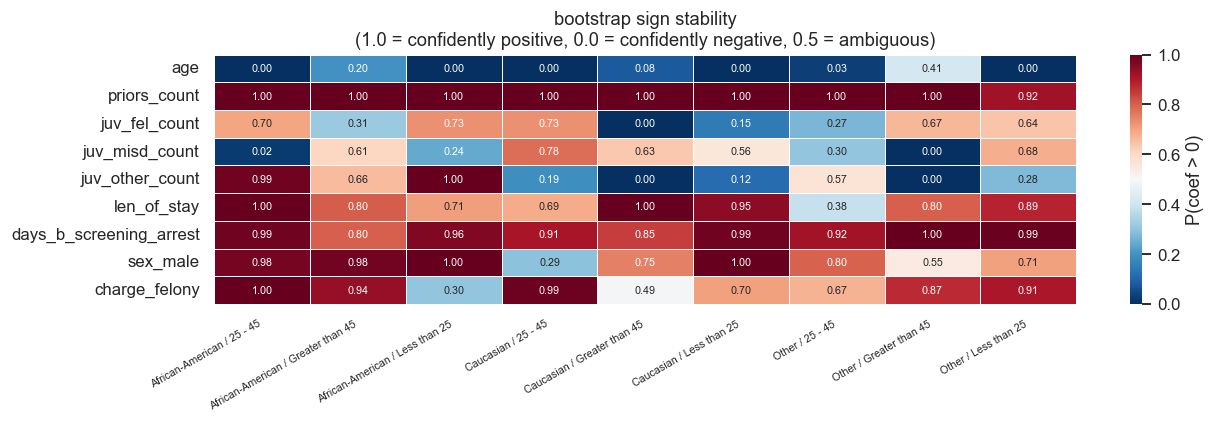

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(sign_prob, annot=True, fmt=".2f", center=0.5, cmap="RdBu_r",
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 7},
            cbar_kws={"label": "P(coef > 0)"})
ax.set_title("bootstrap sign stability\n(1.0 = confidently positive, 0.0 = confidently negative, 0.5 = ambiguous)")
plt.xticks(rotation=30, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

In [34]:
# a flip is credible only if, for both groups involved:
#   - the feature has at least min_support nonzero values in the group
#   - the bootstrap sign is stable (>= 95% one way, <= 5% the other)
#   - the point-estimate coefficient is at least MIN_MAG away from zero

MIN_MAG = 0.10

HI, LO = 0.95, 0.05

# point-estimate coefficients per group
point = pd.DataFrame(cell_coefs)

print("credible flips (sign stable + coefficient not tiny + feature actually varies in the group)")
print("=" * 78)

credible = []
for f in MODEL_FEATURES:
    ok_groups = [g for g in point.columns if support.loc[f, g] >= MIN_SUPPORT]
    if len(ok_groups) < 2:
        continue

    row = sign_prob.loc[f, ok_groups]
    mag = point.loc[f, ok_groups]

    conf_pos = [g for g in ok_groups if row[g] >= HI and mag[g] >= MIN_MAG]
    conf_neg = [g for g in ok_groups if row[g] <= LO and mag[g] <= -MIN_MAG]

    if conf_pos and conf_neg:
        credible.append(f)
        print(f"\n{f}")
        print(f"  confidently positive in: {conf_pos}")
        print(f"  confidently negative in: {conf_neg}")

if not credible:
    print("\nnone. no feature has a sign flip that survives all three checks.")

print()
print("naive flips (coefficient heatmap only) :", naive_flips)
print("credible flips:", credible)

credible flips (sign stable + coefficient not tiny + feature actually varies in the group)

none. no feature has a sign flip that survives all three checks.

naive flips (coefficient heatmap only) : ['juv_fel_count', 'juv_misd_count', 'juv_other_count']
credible flips: []


Result: no credible coefficient flips at race x age granularity.

- Three features look like they flip from the coefficient heatmap.
- Two of those three fail the bootstrap because their signs are coin flips across resamples.
- The last one, `juv_other_count`, passes the bootstrap sign test but only because the "negative"
  groups have zero and one nonzero observation respectively. Once we require the feature to actually
  vary in the group, it disappears too

So the direction of every feature that is actually estimable is the same in every race x age cell.
More priors means more recidivism everywhere. Older means less recidivism everywhere. The groups
disagree about magnitude, not about direction.

### Does fitting per group actually buy anything out of sample?

Separate from the coefficient question,if the groups
really need different models, then per-group models should predict held out data better than the
global model does. If they do not, then whatever heterogeneity exists is not exploitable.

1. global: one model on everyone
2. per group: one model per race x age cell
3. per random group: same number of groups, same group sizes, but membership shuffled

Number 3 is the control. If the real groups do not beat the random groups, then any apparent gain
from splitting is just the effect of fitting more parameters on less data, not real structure.

In [35]:
def cv_compare(X, y, groups, features, n_splits=5, min_n=100, seed=SEED):
    # cross validated log loss and accuracy, global model vs per group models.
    # every prediction is made on a fold the model did not see.
    # if a group is too thin inside a training fold, it falls back to the global model.
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    groups = pd.Series(np.asarray(groups))

    p_glob = np.zeros(len(y))
    p_loc = np.zeros(len(y))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, te_idx in skf.split(X, y):
        Xtr, ytr = X.iloc[tr_idx], y.iloc[tr_idx]
        Xte = X.iloc[te_idx]

        gm = make_pipeline(StandardScaler(),
                           LogisticRegression(C=1.0, max_iter=2000, random_state=seed))
        gm.fit(Xtr, ytr)
        p_glob[te_idx] = gm.predict_proba(Xte)[:, 1]

        gtr = groups.iloc[tr_idx]
        gte = groups.iloc[te_idx]
        for g in pd.unique(gte):
            te_mask = (gte == g).values
            tr_mask = (gtr == g).values
            # fall back to the global model when the group is too thin to fit on
            if tr_mask.sum() < min_n or ytr[tr_mask].nunique() < 2:
                p_loc[np.array(te_idx)[te_mask]] = gm.predict_proba(Xte[te_mask])[:, 1]
                continue
            lm = make_pipeline(StandardScaler(),
                               LogisticRegression(C=1.0, max_iter=2000, random_state=seed))
            lm.fit(Xtr[tr_mask], ytr[tr_mask])
            p_loc[np.array(te_idx)[te_mask]] = lm.predict_proba(Xte[te_mask])[:, 1]

    res = {
        "global_logloss": log_loss(y, p_glob),
        "local_logloss": log_loss(y, p_loc),
        "global_acc": accuracy_score(y, (p_glob >= 0.5).astype(int)),
        "local_acc": accuracy_score(y, (p_loc >= 0.5).astype(int)),
    }
    res["logloss_improvement"] = res["global_logloss"] - res["local_logloss"]
    return res, p_glob, p_loc

y = df["two_year_recid"].copy()
real, p_glob_cv, p_loc_cv = cv_compare(X, y, df["race_age"], MODEL_FEATURES)

print("5 fold CV on the full dataset, race x age groups")
print(f"  global log loss : {real['global_logloss']:.4f}")
print(f"  per group loss  : {real['local_logloss']:.4f}")
print(f"  improvement     : {real['logloss_improvement']:+.4f}  (positive means per group is better)")
print()
print(f"  global accuracy : {real['global_acc']:.4f}")
print(f"  per group acc   : {real['local_acc']:.4f}")

5 fold CV on the full dataset, race x age groups
  global log loss : 0.6075
  per group loss  : 0.6052
  improvement     : +0.0023  (positive means per group is better)

  global accuracy : 0.6847
  per group acc   : 0.6811


In [36]:
# shuffle the group labels so group sizes are preserved but membership is meaningless
# if the real improvement is inside this null distribution, there is nothing to exploit

N_PERM = 100
rng = np.random.default_rng(SEED)
null_improvements = []

for i in range(N_PERM):
    shuffled = df["race_age"].sample(frac=1.0, random_state=int(rng.integers(1e6))).values
    r, _, _ = cv_compare(X, y, shuffled, MODEL_FEATURES)
    null_improvements.append(r["logloss_improvement"])

null_improvements = np.array(null_improvements)

print()
print(f"real improvement          : {real['logloss_improvement']:+.4f}")
print(f"null mean improvement     : {null_improvements.mean():+.4f}")
print(f"null std                  : {null_improvements.std():.4f}")
print(f"fraction of null runs >= real: {(null_improvements >= real['logloss_improvement']).mean():.3f}")


real improvement          : +0.0023
null mean improvement     : -0.0113
null std                  : 0.0023
fraction of null runs >= real: 0.000


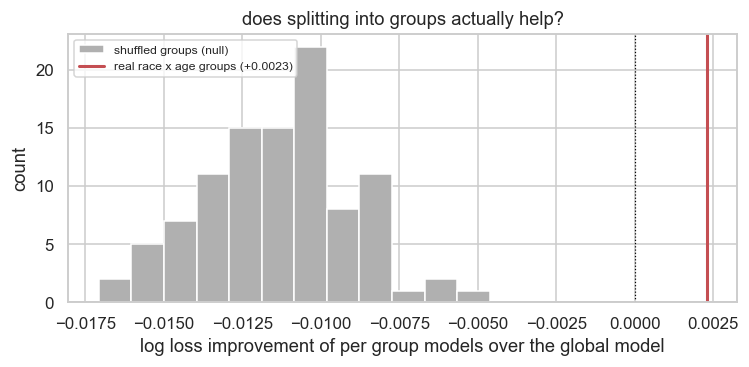

In [37]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(null_improvements, bins=12, color="#B0B0B0", label="shuffled groups (null)")
ax.axvline(real["logloss_improvement"], color="#C44E52", lw=2,
           label=f"real race x age groups ({real['logloss_improvement']:+.4f})")
ax.axvline(0, color="black", lw=0.8, ls=":")
ax.set_xlabel("log loss improvement of per group models over the global model")
ax.set_ylabel("count")
ax.set_title("does splitting into groups actually help?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

                             group    n  global_logloss  local_logloss  improvement
              Other / Less than 25  191          0.6445         0.6719      -0.0274
       Caucasian / Greater than 45  628          0.5274         0.5399      -0.0125
           Other / Greater than 45  197          0.5162         0.5269      -0.0107
African-American / Greater than 45  468          0.6219         0.6252      -0.0034
               Caucasian / 25 - 45 1128          0.6404         0.6420      -0.0017
                   Other / 25 - 45  506          0.6024         0.6023       0.0001
        African-American / 25 - 45 1898          0.5990         0.5986       0.0004
   African-American / Less than 25  809          0.6325         0.6102       0.0223
          Caucasian / Less than 25  347          0.6534         0.6132       0.0402


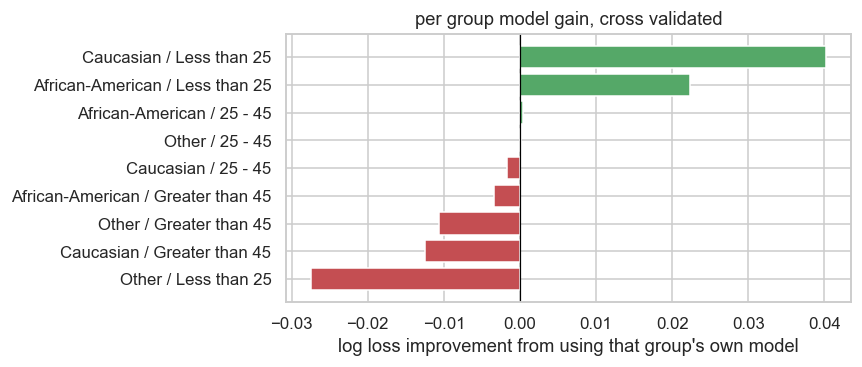

In [38]:
# where does the per group model help or hurt, group by group?

per_group_gain = []
for g in sorted(df["race_age"].unique()):
    m = (df["race_age"] == g).values
    if m.sum() < 100:
        continue
    per_group_gain.append({
        "group": g,
        "n": int(m.sum()),
        "global_logloss": log_loss(y[m], p_glob_cv[m], labels=[0, 1]),
        "local_logloss": log_loss(y[m], p_loc_cv[m], labels=[0, 1]),
    })

gain = pd.DataFrame(per_group_gain)
gain["improvement"] = gain["global_logloss"] - gain["local_logloss"]
gain = gain.sort_values("improvement")
print(gain.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#55A868" if v > 0 else "#C44E52" for v in gain["improvement"]]
ax.barh(gain["group"], gain["improvement"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("log loss improvement from using that group's own model")
ax.set_title("per group model gain, cross validated")
plt.tight_layout()
plt.show()

So per group models don't help